---
title: "Figures: Uncertainty, Risk Aversion, and Prudence"
execute:
  depends_on_env: [IC_EXEC_ENV]
---

Draws the four figures in [Uncertainty, Risk Aversion, and Prudence](#sec:UncertaintyRiskAversionAndPrudence) and computes the chapter's numerical example. Run all the cells to redraw the figures into `figures/`; change the parameters to see how they respond.

The first two figures were drawn by Carroll's *Mathematica* for the handout "Risk Premia and Precautionary Premia"; the last two by the *Mathematica* for Carroll and Kimball's entry "Precautionary Saving and Precautionary Wealth" in *The New Palgrave Dictionary of Economics*, in its public repository [`llorracc/PalgravePrecautionary`](https://github.com/llorracc/PalgravePrecautionary). Here the first two are drawn for the numerical example, so their marked points are the premia the chapter reports.

In [ ]:
# Run anywhere: install the book's package (it brings econ-ark, numpy and matplotlib) if it
# is missing. Inside the book's own environment this does nothing.
try:
    import intertemporal_choice
except ImportError:
    %pip install -q git+https://github.com/intertemporal-choice/intertemporal-choice.github.io

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from HARK.ConsumptionSaving.TractableBufferStockModel import TractableConsumerType

from intertemporal_choice import style

style.use_book_style()

## The numerical example

CRRA utility $\mathrm{u}(c) = c^{1-\rho}/(1-\rho)$, so $\mathrm{u}^{\prime}(c) = c^{-\rho}$. Consumption would be $\bar{c}$ for certain, and the risk $\epsilon$ is $-\alpha$ or $+\alpha$ with probability one half each. The risk premium $\pi^{*}$ and the precautionary premium $\mu^{*}$ solve

$$\mathrm{u}(\bar{c}-\pi^{*}) = \mathbb{E}[\mathrm{u}(\bar{c}+\epsilon)], \qquad \mathrm{u}^{\prime}(\bar{c}-\mu^{*}) = \mathbb{E}[\mathrm{u}^{\prime}(\bar{c}+\epsilon)],$$

and both functions can be inverted in closed form.

In [ ]:
rho = 6.0      # relative risk aversion
c_bar = 3.0    # consumption without the risk
alpha = 0.75   # the risk: consumption is c_bar - alpha or c_bar + alpha


def u(c, rho):
    return c ** (1 - rho) / (1 - rho)


def u_inverse(x, rho):
    return ((1 - rho) * x) ** (1 / (1 - rho))


def uP(c, rho):
    return c ** -rho


def uP_inverse(x, rho):
    return x ** (-1 / rho)


outcomes = np.array([c_bar - alpha, c_bar + alpha])  # equally likely
pi_star = c_bar - u_inverse(u(outcomes, rho).mean(), rho)
mu_star = c_bar - uP_inverse(uP(outcomes, rho).mean(), rho)

# The second-order approximations: half the variance times absolute risk aversion, rho/c,
# and times absolute prudence, (rho+1)/c.
variance = alpha**2
pi_approx = variance / 2 * rho / c_bar
mu_approx = variance / 2 * (rho + 1) / c_bar

print(f"risk premium          pi* = {pi_star:.3f}   approximation {pi_approx}")
print(f"precautionary premium mu* = {mu_star:.3f}   approximation {mu_approx}")

risk premium          pi* = 0.454   approximation 0.5625
precautionary premium mu* = 0.494   approximation 0.65625


These checks stop the build if the numbers above stop being the ones the chapter quotes.

In [ ]:
assert np.isclose(pi_star, 0.454, atol=5e-4) and np.isclose(mu_star, 0.494, atol=5e-4)
assert np.isclose(pi_approx, 0.5625) and np.isclose(mu_approx, 0.65625)
assert pi_star < mu_star and pi_star < pi_approx and mu_star < mu_approx

## The two premia

Each figure marks the two outcomes on the curve, joins them with a chord, and reads the chord's midpoint, the expectation, back to the curve.

In [ ]:
def premium_figure(f, premium, premium_name, f_name):
    """Draw f, the chord between the two outcomes, and the premium it implies."""
    c = np.linspace(c_bar - 1.35 * alpha, c_bar + 1.6 * alpha, 400)
    expectation = f(outcomes).mean()
    bottom = f(c).min() if f(c[0]) < f(c[-1]) else 0  # u's axis starts at the curve's foot

    fig, ax = plt.subplots()
    ax.plot(c, f(c), color="C0")
    ax.plot(outcomes, f(outcomes), color="black", linestyle=":", linewidth=1.0)
    for x, y in [*zip(outcomes, f(outcomes)), (c_bar, expectation), (c_bar - premium, expectation)]:
        ax.vlines(x, bottom, y, color="black", linestyle="--", linewidth=0.8)
        ax.plot(x, y, "o", color="black", markersize=3)
    ax.hlines(expectation, c[0], c_bar, color="black", linestyle="--", linewidth=0.8)
    ax.annotate(rf"$\leftarrow \mathbb{{E}}[{f_name}(\bar{{c}}+\epsilon)]$", (c_bar, expectation),
                xytext=(6, 0), textcoords="offset points", va="center")

    ax.set_xlim(c[0], c[-1])
    ax.set_ylim(bottom, None)
    ax.set_xticks([outcomes[0], c_bar - premium, c_bar, outcomes[1]])
    ax.set_xticklabels([r"$\bar{c}-\alpha$", rf"$\bar{{c}}-{premium_name}$", r"$\bar{c}$", r"$\bar{c}+\alpha$"])
    ax.set_yticks([expectation])
    ax.set_yticklabels([rf"${f_name}(\bar{{c}}-{premium_name})$"])
    ax.set_xlabel(r"$c$", loc="right")
    ax.set_ylabel(rf"${f_name}(c)$", loc="top", rotation=0)
    return fig

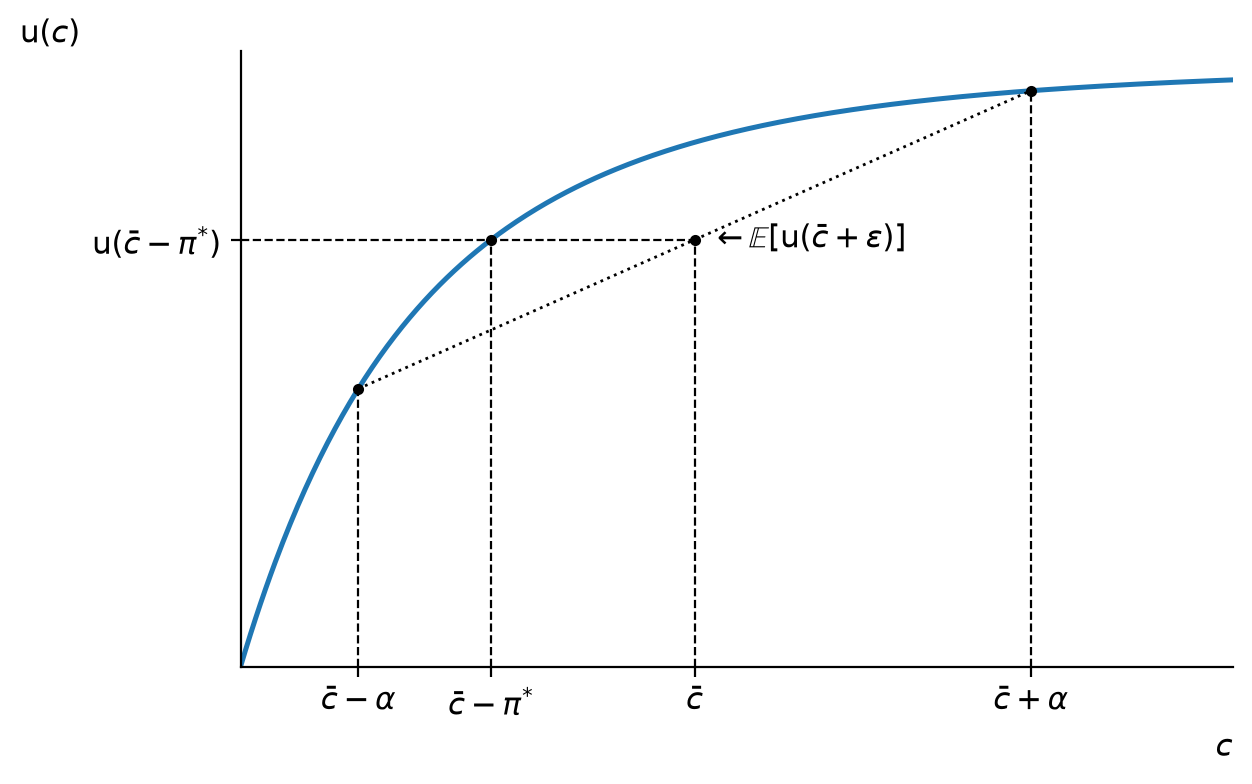

In [ ]:
fig = premium_figure(lambda c: u(c, rho), pi_star, r"\pi^{*}", r"\mathrm{u}")
style.save(fig, "RiskPremium")

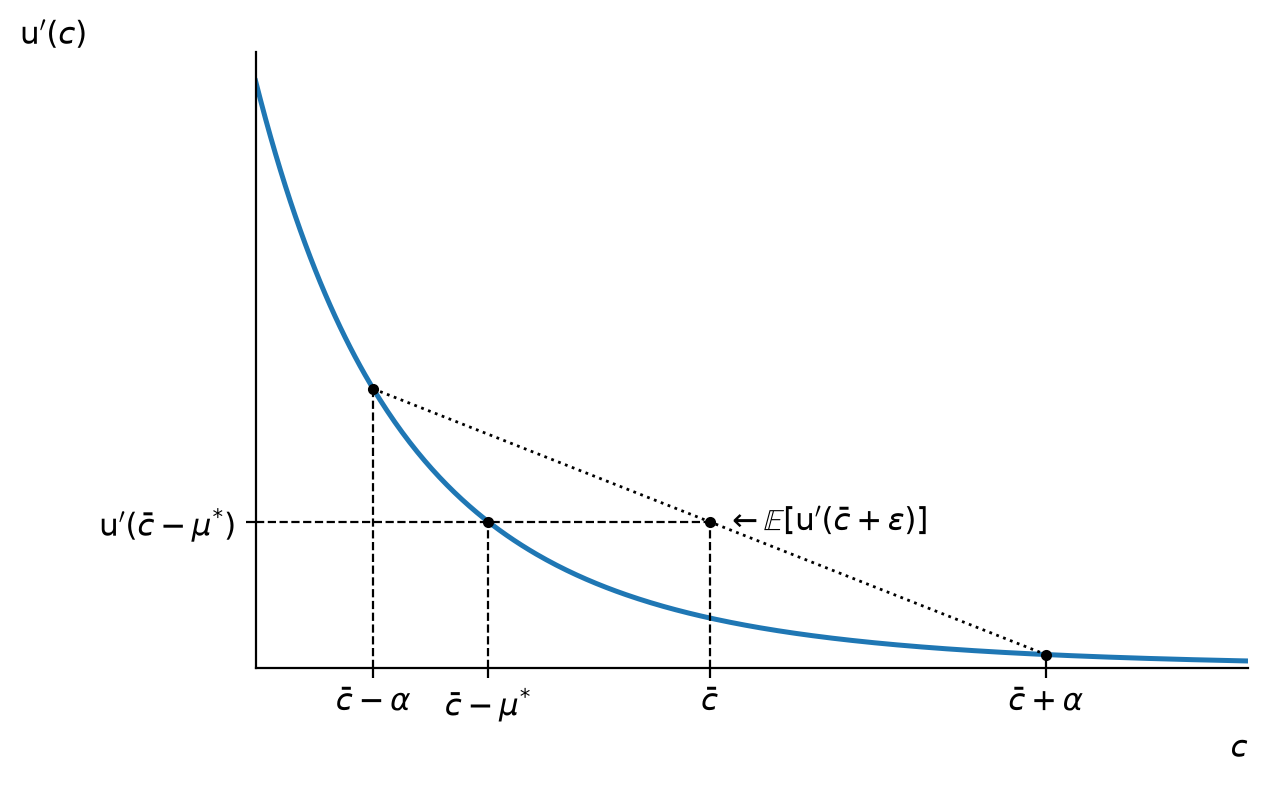

In [ ]:
fig = premium_figure(lambda c: uP(c, rho), mu_star, r"\mu^{*}", r"\mathrm{u}^{\prime}")
style.save(fig, "PrecautionaryPremium")

## Precautionary saving in the consumer's choice

The consumer has resources $m_{t}$ and chooses end-of-period assets $a_{t}$, consuming $m_{t}-a_{t}$. Period $t+1$ is the last, so its value function is utility, $\mathrm{v}_{t+1} = \mathrm{u}$, and the marginal value of ending period $t$ with assets $a$ is

$$\mathfrak{v}^{\prime}_{t}(a) = \beta \mathsf{R}\, \mathbb{E}_{t}[\mathrm{u}^{\prime}(\mathsf{R} a + \tilde{y}_{t+1})].$$

Income $\tilde{y}_{t+1}$ is $\bar{y}-\sigma$ or $\bar{y}+\sigma$ with probability one half each, or $\bar{y}$ for certain. The optimal $a$ equates $\mathrm{u}^{\prime}(m_{t}-a)$ to $\mathfrak{v}^{\prime}_{t}(a)$: $a^{*}$ without the risk, $a^{**}$ with it.

In [ ]:
rho_2 = 2.0                   # relative risk aversion
beta, R = 1.0, 1.0            # time preference and interest factors
m_t = 3.0                     # resources in period t
y_bar, sigma = 1.0, 0.75      # income next period: y_bar - sigma or y_bar + sigma


def end_marginal_value(a, incomes):
    """beta R E[u'(R a + y)], averaging over equally likely incomes."""
    return beta * R * np.mean([uP(R * a + y, rho_2) for y in incomes], axis=0)


def optimal_a(incomes):
    return brentq(lambda a: uP(m_t - a, rho_2) - end_marginal_value(a, incomes), 1e-9, m_t - 1e-9)


certain, risky = [y_bar], [y_bar - sigma, y_bar + sigma]
a_star, a_star_star = optimal_a(certain), optimal_a(risky)
print(f"a* = {a_star:.3f}, a** = {a_star_star:.3f}: precautionary saving {a_star_star - a_star:.3f}")
assert a_star_star > a_star

a* = 1.000, a** = 1.181: precautionary saving 0.181


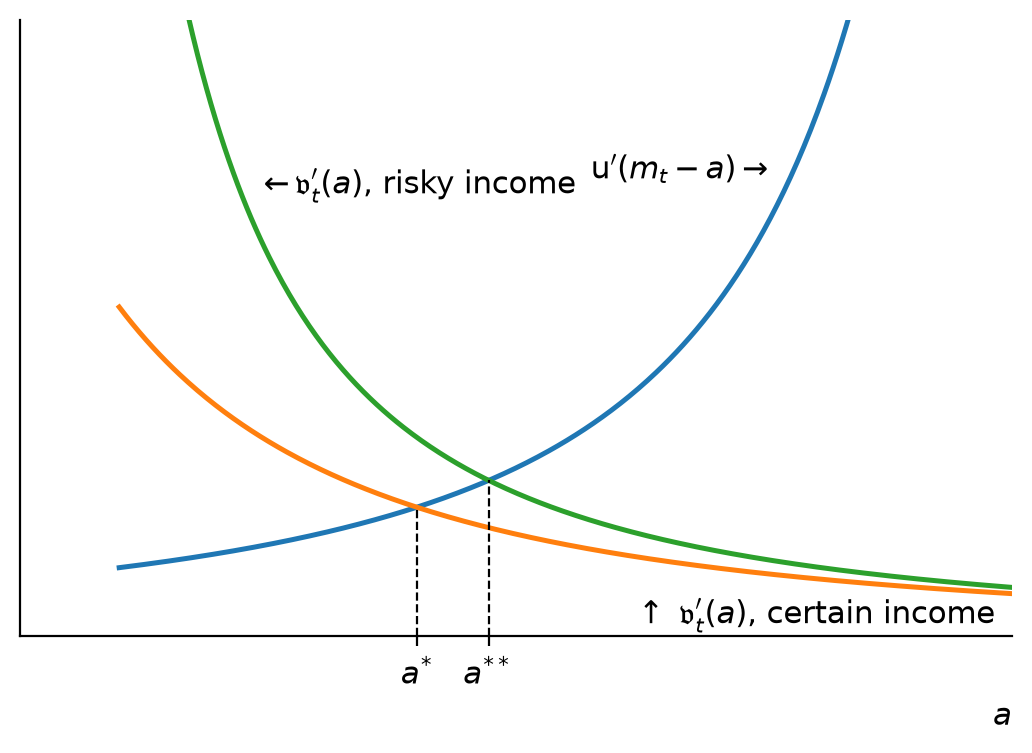

In [ ]:
a = np.linspace(0.25, 2.5, 400)
fig, ax = plt.subplots()
ax.plot(a, uP(m_t - a, rho_2), color="C0")
ax.plot(a, end_marginal_value(a, certain), color="C1")
ax.plot(a, end_marginal_value(a, risky), color="C2")
for x in (a_star, a_star_star):
    ax.vlines(x, 0, uP(m_t - x, rho_2), color="black", linestyle="--", linewidth=0.8)

ax.text(1.95, uP(m_t - 1.95, rho_2), r"$\mathrm{u}^{\prime}(m_{t}-a) \rightarrow$  ", ha="right", va="center")
ax.text(0.55, end_marginal_value(0.55, risky), r"  $\leftarrow \mathfrak{v}^{\prime}_{t}(a)$, risky income", ha="left", va="center")
ax.text(2.0, 0.9 * end_marginal_value(a[-1], certain), r"$\uparrow$ $\mathfrak{v}^{\prime}_{t}(a)$, certain income", ha="center", va="top")

ax.set_xlim(0, a[-1])
ax.set_ylim(0, 1.2)
ax.set_xticks([a_star, a_star_star])
ax.set_xticklabels([r"$a^{*}$", r"$a^{**}$"])
ax.set_yticks([])
ax.set_xlabel(r"$a$", loc="right")
style.save(fig, "EquateMargUtils")

## The consumption function and the target

The tractable model of buffer stock saving: an employed consumer faces a small probability $\mho$ each period of losing labor income for good. HARK's `TractableConsumerType` solves it, here for the benchmark parameters of the chapter on that model. Everything is normalized by permanent labor income, which is $1$.

The figure shows the consumption function of the employed consumer, $\mathrm{c}(m)$; the consumption function of a consumer facing no risk whose income grows at the same expected rate, $\bar{\mathrm{c}}(m)$; and the level of consumption that leaves $m$ unchanged next period if the consumer stays employed. That line crosses $\mathrm{c}(m)$ at the target, $\check{m}$.

In [ ]:
mho = 0.005          # probability of losing labor income for good
beta_tbs = 1 / 1.10  # time preference factor
R_tbs = 1.03         # interest factor
Gamma = 1.0          # growth factor of permanent labor income
rho_tbs = 2.0        # relative risk aversion

worker = TractableConsumerType(UnempPrb=mho, DiscFac=beta_tbs, Rfree=R_tbs, PermGroFac=Gamma, CRRA=rho_tbs)
worker.solve()
m_target, c_target = worker.mTarg, worker.cTarg


def c(m):
    return worker.solution[0].cFunc(m)


def c_bar_pf(m):
    """Perfect foresight: the MPC kappa times market resources plus human wealth, less this period's income."""
    return (m - 1 + worker.h) * worker.PFMPC


def m_unchanged(m):
    """Consumption that leaves m unchanged next period for a consumer who stays employed."""
    return worker.mSSfunc(m)


m = np.linspace(0, 1.9 * m_target, 400)
print(f"target m = {m_target:.5f}, c at target = {c_target:.5f}")

# Precautionary saving is positive, the consumption function is concave, and the target is
# where c(m) crosses the line along which m stays put.
assert np.all(c(m[1:]) < c_bar_pf(m[1:]))
assert np.all(np.diff(c(m), 2) < 1e-12)
assert np.isclose(c(m_target), m_unchanged(m_target))
assert np.isclose(m_target, 5.47585, atol=5e-6) and np.isclose(c_target, 1.10853, atol=5e-6)

target m = 5.47585, c at target = 1.10853


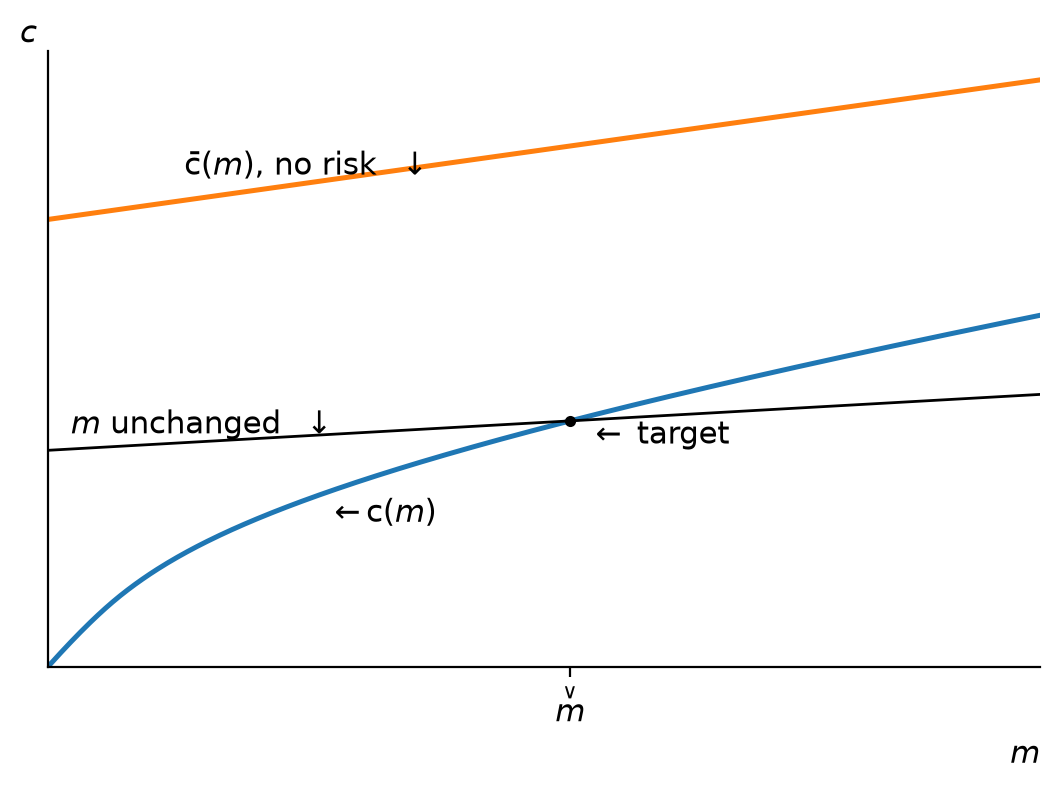

In [ ]:
fig, ax = plt.subplots()
ax.plot(m, c(m), color="C0")
ax.plot(m, c_bar_pf(m), color="C1")
ax.plot(m, m_unchanged(m), color="black", linewidth=1.0)
ax.plot(m_target, c_target, "o", color="black", markersize=3)

ax.text(0.5 * m_target, c(0.5 * m_target), r"  $\leftarrow \mathrm{c}(m)$", ha="left", va="top")
ax.text(0.5 * m_target, c_bar_pf(0.5 * m_target), r"$\bar{\mathrm{c}}(m)$, no risk  $\downarrow$", ha="center", va="bottom")
ax.text(0.3 * m_target, m_unchanged(0.3 * m_target), r"$m$ unchanged  $\downarrow$", ha="center", va="bottom")
ax.text(m_target, c_target, r"  $\leftarrow$ target", ha="left", va="top")

ax.set_xlim(0, m[-1])
ax.set_ylim(0, None)
ax.set_xticks([m_target])
ax.set_xticklabels([r"$\overset{\vee}{m}$"])
ax.set_yticks([])
ax.set_xlabel(r"$m$", loc="right")
ax.set_ylabel(r"$c$", loc="top", rotation=0)
style.save(fig, "ConsFuncTarget")